This notebook contains steps to map members of the SARS-CoV-2 innate immunity evasion and cell-specific immune response (WP5039) pathway extracted from Wiki pathways to the multi-omics data from the FDC-TWOC example, using Bridge DB. The FDC-TWOC example shows the process of onboarding meta-data on the FDP, connecting the data to a triple store endpoint and using SPARQL queries to retrieve data from the triple store. This is to demonstrate how multi-omics analysis can be done with the FAIR Data Cube. 

This notebook specifically aims to add a pathway layer of information by mapping the different omics measurements obtained from the queries to the pathway members, so they can be further analysed. 

In [131]:
import requests
from bridgedb_script import get_mappings
import pandas as pd

Read in the data from wikipathways for the SARS_CoV_2 immunity pathway

Read in the proteomics data from the SPARQL queries

In [132]:
proteo_df = pd.read_csv('/Users/firdaws/Documents/TWOCdemonstrator/data/Su_2020_FAIR/proteomics/proteomics_Su_2020_feature-metadata.csv')
proteo_df.head()

,feature.name,Unnamed: 0,database.ID,database,database.version,Uniprot_ID
0,eukaryotic translation initiation factor 4E bi...,0,4EBP1_HUMAN,https://www.uniprot.org/uniprotkb/,UniProtKB/Swiss-Prot Release 2022_03,Q13541
1,adenosine deaminase,1,ADA_HUMAN,https://www.uniprot.org/uniprotkb/,UniProtKB/Swiss-Prot Release 2022_03,P00813
2,adrenomedullin,2,ADML_HUMAN,https://www.uniprot.org/uniprotkb/,UniProtKB/Swiss-Prot Release 2022_03,P35318
3,anterior gradient 2,3,AGR3_HUMAN,https://www.uniprot.org/uniprotkb/,UniProtKB/Swiss-Prot Release 2022_03,Q8TD06
4,egf-like module containing mucin-like hormone ...,4,AGRE2_HUMAN,https://www.uniprot.org/uniprotkb/,UniProtKB/Swiss-Prot Release 2022_03,Q9UHX3


In [133]:
#proteo_df.set_index('feature.name', inplace=True)
# update the proteomics file to include UNIPROT_IDS
#proteo_df.to_csv('/Users/firdaws/Documents/TWOCdemonstrator/data/Su_2020_FAIR/proteomics/proteomics_Su_2020_feature-metadata.csv')

In [134]:
# proteinID_df = pd.read_csv('/Users/firdaws/Documents/TWOCdemonstrator/data/Su_2020_FAIR/idmapping_2024_07_11.tsv', sep='\t')
# proteinID_df_filterd = proteinID_df[['From', 'Entry']]
# proteinID_df.head()

In [135]:
# mapped_df = proteo_df.merge(proteinID_df_filterd, left_on='database.ID', right_on='From', how='left' )
# mapped_df.drop(columns=['From'], inplace=True)

In [136]:
# mapped_df.rename(columns={'Entry': 'Uniprot_ID'}, inplace=True)
# mapped_df.head()

In [137]:
# proteomics_ids = proteo_df['Uniprot_ID']
# proteomics_ids.to_csv('proteo_IDS.tsv', sep='\t', header=False)

In [138]:
# update the proteomics file to include UNIPROT_IDS
#mapped_df.to_csv('/Users/firdaws/Documents/TWOCdemonstrator/data/Su_2020_FAIR/proteomics/proteomics_Su_2020_feature-metadata.csv')

Connect to the BridgeDB API

In [139]:
url = "https://webservice.bridgedb.org/"
batch_request = url+"{org}/xrefsBatch/{source}{}"

In [140]:
# Check if the mapping type required is available
mapping_available = "{org}/isMappingSupported/{source}/{target}"
query = url+mapping_available.format(org='Homo sapiens', source='S', target='En')
requests.get(query).text

'true'

In [141]:
# function to process response from the API
def to_df(response, batch=False):
    if batch:
        records = []
        for tup in to_df(response).itertuples():
            if tup[3] != None:
                for mappings in tup[3].split(','):
                    target = mappings.split(':', 1)
                    if len(target) > 1:
                        records.append((tup[1], tup[2], target[1], target[0]))
                    else:
                        records.append((tup[1], tup[2], target[0], target[0]))
        return pd.DataFrame(records, columns = ['original', 'source', 'mapping', 'target'])
        
    return pd.DataFrame([line.split('\t') for line in response.text.split('\n')])

In [142]:
# extract the ID column required for mapping
data = proteo_df['Uniprot_ID']

In [143]:
data

0      Q13541
1      P00813
2      P35318
3      Q8TD06
4      Q9UHX3
        ...  
246    Q7L8A9
247    P15692
248    P49767
249    P42768
250    Q05516
Name: Uniprot_ID, Length: 251, dtype: object

In [144]:
# do mapping
query = batch_request.format('?dataSource=En', org='Homo sapiens', source='S')
response = requests.post(query, data=data.to_csv(index=False, header=False))

In [145]:
mapped =to_df(response, batch=True)
mapped

,original,source,mapping,target
0,Q13541,Uniprot-TrEMBL,6BCX,Pd
1,Q13541,Uniprot-TrEMBL,GO:0006417,T
2,Q13541,Uniprot-TrEMBL,6BCU,Pd
3,Q13541,Uniprot-TrEMBL,NM_004095,Q
4,Q13541,Uniprot-TrEMBL,54152_at,X
...,...,...,...,...
29104,Q05516,Uniprot-TrEMBL,3349722,X
29105,Q05516,Uniprot-TrEMBL,3349723,X
29106,Q05516,Uniprot-TrEMBL,ILMN_2402817,Il
29107,Q05516,Uniprot-TrEMBL,231262_at,X


In [146]:
# Select rows where the target column has the value 'En'
filtered_df = mapped[mapped['target'] == 'En']

# Print the filtered DataFrame
print(filtered_df)

      original          source          mapping target
11      Q13541  Uniprot-TrEMBL  ENSG00000187840     En
215     P00813  Uniprot-TrEMBL  ENSG00000196839     En
221     P35318  Uniprot-TrEMBL  ENSG00000148926     En
360     Q8TD06  Uniprot-TrEMBL  ENSG00000173467     En
467     Q9UHX3  Uniprot-TrEMBL  ENSG00000127507     En
...        ...             ...              ...    ...
28267   Q7L8A9  Uniprot-TrEMBL  ENSG00000071246     En
28536   P15692  Uniprot-TrEMBL  ENSG00000112715     En
28808   P49767  Uniprot-TrEMBL  ENSG00000150630     En
28822   P42768  Uniprot-TrEMBL  ENSG00000015285     En
28995   Q05516  Uniprot-TrEMBL  ENSG00000109906     En

[249 rows x 4 columns]


In [147]:
final_proteo_mapped = proteo_df.merge(filtered_df, left_on='Uniprot_ID', right_on='original', how='left')
final_proteo_mapped.head()

,feature.name,Unnamed: 0,database.ID,database,database.version,Uniprot_ID,original,source,mapping,target
0,eukaryotic translation initiation factor 4E bi...,0,4EBP1_HUMAN,https://www.uniprot.org/uniprotkb/,UniProtKB/Swiss-Prot Release 2022_03,Q13541,Q13541,Uniprot-TrEMBL,ENSG00000187840,En
1,adenosine deaminase,1,ADA_HUMAN,https://www.uniprot.org/uniprotkb/,UniProtKB/Swiss-Prot Release 2022_03,P00813,P00813,Uniprot-TrEMBL,ENSG00000196839,En
2,adrenomedullin,2,ADML_HUMAN,https://www.uniprot.org/uniprotkb/,UniProtKB/Swiss-Prot Release 2022_03,P35318,P35318,Uniprot-TrEMBL,ENSG00000148926,En
3,anterior gradient 2,3,AGR3_HUMAN,https://www.uniprot.org/uniprotkb/,UniProtKB/Swiss-Prot Release 2022_03,Q8TD06,Q8TD06,Uniprot-TrEMBL,ENSG00000173467,En
4,egf-like module containing mucin-like hormone ...,4,AGRE2_HUMAN,https://www.uniprot.org/uniprotkb/,UniProtKB/Swiss-Prot Release 2022_03,Q9UHX3,Q9UHX3,Uniprot-TrEMBL,ENSG00000127507,En


In [148]:
# get mapped Ensemble IDS
proteo_ensmbl_ids = final_proteo_mapped['mapping']
proteo_ensmbl_ids

0      ENSG00000187840
1      ENSG00000196839
2      ENSG00000148926
3      ENSG00000173467
4      ENSG00000127507
            ...       
258    ENSG00000071246
259    ENSG00000112715
260    ENSG00000150630
261    ENSG00000015285
262    ENSG00000109906
Name: mapping, Length: 263, dtype: object

In [149]:
## Load in the Sars-cov_-2 Pathway file
SC2_path = pd.read_csv('/Users/firdaws/Documents/TWOCdemonstrator/data/Su_2020_FAIR/pathway.tsv', sep='\t')
SC2_path.head()

,Label,Type,Identifier,Comment,Ensembl,NCBI gene,HGNC,UniProt,Wikidata,ChEBI,InChI
0,Interferon gamma-1b,Metabolite,wikidata:Q582356,NaN,NaN,NaN,NaN,NaN,wikidata:Q582356,NaN,NaN
1,CXCL2,GeneProduct,ncbigene:2920,NaN,ensembl:ENSG00000081041,ncbigene:2920,hgnc.symbol:CXCL2,uniprot:A0A024RDD9;uniprot:P19875,NaN,NaN,NaN
2,CXCL3,GeneProduct,ensembl:ENSG00000163734,NaN,ensembl:ENSG00000163734,ncbigene:2921,hgnc.symbol:CXCL3,uniprot:P19876,NaN,NaN,NaN
3,CXCL4,GeneProduct,ensembl:ENSG00000163737,NaN,ensembl:ENSG00000163737,ncbigene:5196,hgnc.symbol:PF4,uniprot:P02776,NaN,NaN,NaN
4,CXCL5,GeneProduct,ensembl:ENSG00000163735,NaN,ensembl:ENSG00000163735,ncbigene:6374,hgnc.symbol:CXCL5,uniprot:P42830;uniprot:Q6I9S7,NaN,NaN,NaN


In [150]:
print(len(SC2_path))

108


In [151]:
# get ensmbl ids for all proteins found in the pathways
SC2_path_filtered = SC2_path.dropna(subset=['Ensembl']).copy()
SC2_path_filtered['Ensembl'] = SC2_path_filtered['Ensembl'].str.replace('ensembl:', '', regex=False)
# # data2 = data2.dropna()
# # data2 = data2.str.replace('ensembl:', '', regex=False)
# # data2.head()
SC2_path_filtered.head()


,Label,Type,Identifier,Comment,Ensembl,NCBI gene,HGNC,UniProt,Wikidata,ChEBI,InChI
1,CXCL2,GeneProduct,ncbigene:2920,NaN,ENSG00000081041,ncbigene:2920,hgnc.symbol:CXCL2,uniprot:A0A024RDD9;uniprot:P19875,NaN,NaN,NaN
2,CXCL3,GeneProduct,ensembl:ENSG00000163734,NaN,ENSG00000163734,ncbigene:2921,hgnc.symbol:CXCL3,uniprot:P19876,NaN,NaN,NaN
3,CXCL4,GeneProduct,ensembl:ENSG00000163737,NaN,ENSG00000163737,ncbigene:5196,hgnc.symbol:PF4,uniprot:P02776,NaN,NaN,NaN
4,CXCL5,GeneProduct,ensembl:ENSG00000163735,NaN,ENSG00000163735,ncbigene:6374,hgnc.symbol:CXCL5,uniprot:P42830;uniprot:Q6I9S7,NaN,NaN,NaN
5,CXCL6,GeneProduct,ncbigene:6372,NaN,ENSG00000124875,ncbigene:6372,hgnc.symbol:CXCL6,uniprot:D6RF92;uniprot:P80162,NaN,NaN,NaN


Connecting the pathway members to the Proteomics Data

In [152]:
# check the ensemble ids from the proteomics data that are present in the pathway data
# Extract the columns of interest
proteo_ids = proteo_ensmbl_ids
pathway_ids = SC2_path_filtered['Ensembl']

# Find common values
common_values = pd.Series(list(set(proteo_ids) & set(pathway_ids)))

# Print the common values
print("Common values:", common_values.tolist())

# If you want to save the result into a list
common_values_list = common_values.tolist()

Common values: ['ENSG00000127191', 'ENSG00000136634', 'ENSG00000089692']


In [153]:
proteo_in_pathway = final_proteo_mapped[final_proteo_mapped['mapping'].isin(common_values)]
proteo_in_pathway

,feature.name,Unnamed: 0,database.ID,database,database.version,Uniprot_ID,original,source,mapping,target
114,interleukin 10,106,IL10_HUMAN,https://www.uniprot.org/uniprotkb/,UniProtKB/Swiss-Prot Release 2022_03,P22301,P22301,Uniprot-TrEMBL,ENSG00000136634,En
115,interleukin 10,106,IL10_HUMAN,https://www.uniprot.org/uniprotkb/,UniProtKB/Swiss-Prot Release 2022_03,P22301,P22301,Uniprot-TrEMBL,ENSG00000136634,En
116,interleukin 10,107,IL10_HUMAN,https://www.uniprot.org/uniprotkb/,UniProtKB/Swiss-Prot Release 2022_03,P22301,P22301,Uniprot-TrEMBL,ENSG00000136634,En
117,interleukin 10,107,IL10_HUMAN,https://www.uniprot.org/uniprotkb/,UniProtKB/Swiss-Prot Release 2022_03,P22301,P22301,Uniprot-TrEMBL,ENSG00000136634,En
151,lymphocyte-activation gene 3,141,LAG3_HUMAN,https://www.uniprot.org/uniprotkb/,UniProtKB/Swiss-Prot Release 2022_03,P18627,P18627,Uniprot-TrEMBL,ENSG00000089692,En
250,TNF receptor-associated factor 2,238,TRAF2_HUMAN,https://www.uniprot.org/uniprotkb/,UniProtKB/Swiss-Prot Release 2022_03,Q12933,Q12933,Uniprot-TrEMBL,ENSG00000127191,En


In [154]:
proteo_list = set(proteo_in_pathway['feature.name'])
proteo_list

{'TNF receptor-associated factor 2',
 'interleukin 10',
 'lymphocyte-activation gene 3'}

Transcriptomics Data Mapping with pathway Members 

In [155]:
# load the transcriptomics data
trans_df = pd.read_csv('/Users/firdaws/Documents/TWOCdemonstrator/data/Su_2020_FAIR/transcriptomics/transcriptomics_Su_2020_feature-metadata.csv')
trans_df.head()

,feature.name,database.ID,database,database.version
0,A1BG,NM_130786,https://www.ncbi.nlm.nih.gov/nuccore/,RefSeq Release 213
1,A1BG-AS1,NR_015380,https://www.ncbi.nlm.nih.gov/nuccore/,RefSeq Release 213
2,A2M,NM_000014,https://www.ncbi.nlm.nih.gov/nuccore/,RefSeq Release 213
3,A2M-AS1,NR_026971,https://www.ncbi.nlm.nih.gov/nuccore/,RefSeq Release 213
4,A2ML1,NM_001282424,https://www.ncbi.nlm.nih.gov/nuccore/,RefSeq Release 213


In [156]:
# # save IDS
# trans_IDS = trans_df['database.ID']
# trans_IDS.to_csv('trans_IDS.tsv', sep='\t')

In [157]:
# set up bridgeDB
url = "https://webservice.bridgedb.org/"
batch_request = url+"{org}/xrefsBatch/{source}{}"


In [158]:
data = trans_df['database.ID']
data

0             NM_130786
1             NR_015380
2             NM_000014
3             NR_026971
4          NM_001282424
              ...      
18313      NM_001040653
18314      NM_001004339
18315         NM_024646
18316    NM_001010972_2
18317         NM_015113
Name: database.ID, Length: 18318, dtype: object

In [159]:
# do mapping
query = batch_request.format('', org='Homo sapiens', source='Q')
response = requests.post(query, data=data.to_csv(index=False, header=False))


In [160]:
mapped =to_df(response, batch=True)
mapped

,original,source,mapping,target
0,NM_130786,RefSeq,3872844,X
1,NM_130786,RefSeq,3872845,X
2,NM_130786,RefSeq,3872842,X
3,NM_130786,RefSeq,8039748,X
4,NM_130786,RefSeq,HGNC:5,Hac
...,...,...,...,...
1739243,NM_015113,RefSeq,ILMN_1786396,Il
1739244,NM_015113,RefSeq,uc059zsd.1,Uc
1739245,NM_015113,RefSeq,23140,L
1739246,NM_015113,RefSeq,GO:0140566,T


In [161]:
# Select rows where the target column has the value 'En'
filtered_df = mapped[mapped['target'] == 'En']

# Print the filtered DataFrame
print(filtered_df)

             original  source          mapping target
48          NM_130786  RefSeq  ENSG00000121410     En
78          NR_015380  RefSeq  ENSG00000268895     En
197         NM_000014  RefSeq  ENSG00000175899     En
283         NR_026971  RefSeq  ENSG00000245105     En
378      NM_001282424  RefSeq  ENSG00000166535     En
...               ...     ...              ...    ...
1738870     NM_007157  RefSeq  ENSG00000198455     En
1738920  NM_001040653  RefSeq  ENSG00000070476     En
1738980  NM_001004339  RefSeq  ENSG00000203995     En
1739091     NM_024646  RefSeq  ENSG00000162378     En
1739121     NM_015113  RefSeq  ENSG00000074755     En

[17012 rows x 4 columns]


In [162]:
final_trans_mapped = trans_df.merge(filtered_df, left_on='database.ID', right_on='original', how='left')
final_trans_mapped = final_trans_mapped.dropna(subset=['mapping']).copy()
final_trans_mapped

,feature.name,database.ID,database,database.version,original,source,mapping,target
0,A1BG,NM_130786,https://www.ncbi.nlm.nih.gov/nuccore/,RefSeq Release 213,NM_130786,RefSeq,ENSG00000121410,En
1,A1BG-AS1,NR_015380,https://www.ncbi.nlm.nih.gov/nuccore/,RefSeq Release 213,NR_015380,RefSeq,ENSG00000268895,En
2,A2M,NM_000014,https://www.ncbi.nlm.nih.gov/nuccore/,RefSeq Release 213,NM_000014,RefSeq,ENSG00000175899,En
3,A2M-AS1,NR_026971,https://www.ncbi.nlm.nih.gov/nuccore/,RefSeq Release 213,NR_026971,RefSeq,ENSG00000245105,En
4,A2ML1,NM_001282424,https://www.ncbi.nlm.nih.gov/nuccore/,RefSeq Release 213,NM_001282424,RefSeq,ENSG00000166535,En
...,...,...,...,...,...,...,...,...
18312,ZXDB,NM_007157,https://www.ncbi.nlm.nih.gov/nuccore/,RefSeq Release 213,NM_007157,RefSeq,ENSG00000198455,En
18313,ZXDC,NM_001040653,https://www.ncbi.nlm.nih.gov/nuccore/,RefSeq Release 213,NM_001040653,RefSeq,ENSG00000070476,En
18314,ZYG11A,NM_001004339,https://www.ncbi.nlm.nih.gov/nuccore/,RefSeq Release 213,NM_001004339,RefSeq,ENSG00000203995,En
18315,ZYG11B,NM_024646,https://www.ncbi.nlm.nih.gov/nuccore/,RefSeq Release 213,NM_024646,RefSeq,ENSG00000162378,En


In [163]:
SC2_path['Ensembl']=SC2_path['Ensembl'].str.replace('ensembl:', '', regex=False)
SC2_path.head()

,Label,Type,Identifier,Comment,Ensembl,NCBI gene,HGNC,UniProt,Wikidata,ChEBI,InChI
0,Interferon gamma-1b,Metabolite,wikidata:Q582356,NaN,NaN,NaN,NaN,NaN,wikidata:Q582356,NaN,NaN
1,CXCL2,GeneProduct,ncbigene:2920,NaN,ENSG00000081041,ncbigene:2920,hgnc.symbol:CXCL2,uniprot:A0A024RDD9;uniprot:P19875,NaN,NaN,NaN
2,CXCL3,GeneProduct,ensembl:ENSG00000163734,NaN,ENSG00000163734,ncbigene:2921,hgnc.symbol:CXCL3,uniprot:P19876,NaN,NaN,NaN
3,CXCL4,GeneProduct,ensembl:ENSG00000163737,NaN,ENSG00000163737,ncbigene:5196,hgnc.symbol:PF4,uniprot:P02776,NaN,NaN,NaN
4,CXCL5,GeneProduct,ensembl:ENSG00000163735,NaN,ENSG00000163735,ncbigene:6374,hgnc.symbol:CXCL5,uniprot:P42830;uniprot:Q6I9S7,NaN,NaN,NaN


In [164]:
SC2_path = SC2_path.dropna(subset=['Ensembl']).copy()
SC2_path.head()

,Label,Type,Identifier,Comment,Ensembl,NCBI gene,HGNC,UniProt,Wikidata,ChEBI,InChI
1,CXCL2,GeneProduct,ncbigene:2920,NaN,ENSG00000081041,ncbigene:2920,hgnc.symbol:CXCL2,uniprot:A0A024RDD9;uniprot:P19875,NaN,NaN,NaN
2,CXCL3,GeneProduct,ensembl:ENSG00000163734,NaN,ENSG00000163734,ncbigene:2921,hgnc.symbol:CXCL3,uniprot:P19876,NaN,NaN,NaN
3,CXCL4,GeneProduct,ensembl:ENSG00000163737,NaN,ENSG00000163737,ncbigene:5196,hgnc.symbol:PF4,uniprot:P02776,NaN,NaN,NaN
4,CXCL5,GeneProduct,ensembl:ENSG00000163735,NaN,ENSG00000163735,ncbigene:6374,hgnc.symbol:CXCL5,uniprot:P42830;uniprot:Q6I9S7,NaN,NaN,NaN
5,CXCL6,GeneProduct,ncbigene:6372,NaN,ENSG00000124875,ncbigene:6372,hgnc.symbol:CXCL6,uniprot:D6RF92;uniprot:P80162,NaN,NaN,NaN


In [165]:
# Extract the columns of interest
features = SC2_path['Ensembl']
labels = final_trans_mapped['mapping']

# Find common values
common_values = pd.Series(list(set(features) & set(labels)))

# Print the common values
print("Common values:", common_values.tolist())


common_values_list = common_values.tolist()

Common values: ['ENSG00000124875', 'ENSG00000109320', 'ENSG00000169429', 'ENSG00000127191', 'ENSG00000126456', 'ENSG00000168040', 'ENSG00000159110', 'ENSG00000196664', 'ENSG00000137275', 'ENSG00000163737', 'ENSG00000081041', 'ENSG00000138755', 'ENSG00000105329', 'ENSG00000107562', 'ENSG00000089692', 'ENSG00000170581', 'ENSG00000175104', 'ENSG00000155506', 'ENSG00000107201', 'ENSG00000180871', 'ENSG00000169245', 'ENSG00000130234', 'ENSG00000131323', 'ENSG00000157601', 'ENSG00000183735', 'ENSG00000163735', 'ENSG00000196591', 'ENSG00000121060', 'ENSG00000108771', 'ENSG00000137203', 'ENSG00000101146', 'ENSG00000064012', 'ENSG00000119922', 'ENSG00000172270', 'ENSG00000166747', 'ENSG00000163739', 'ENSG00000082512', 'ENSG00000135077', 'ENSG00000142166', 'ENSG00000185885', 'ENSG00000117281', 'ENSG00000088888', 'ENSG00000100393', 'ENSG00000110713', 'ENSG00000115129', 'ENSG00000160712', 'ENSG00000115415', 'ENSG00000189377', 'ENSG00000136634', 'ENSG00000156234', 'ENSG00000108691', 'ENSG0000013656

In [166]:
len(common_values_list)

61

In [167]:
trans_in_pathway = final_trans_mapped[final_trans_mapped['mapping'].isin(common_values)]
trans_in_pathway

,feature.name,database.ID,database,database.version,original,source,mapping,target
137,ACE2,NM_001371415,https://www.ncbi.nlm.nih.gov/nuccore/,RefSeq Release 213,NM_001371415,RefSeq,ENSG00000130234,En
727,AP1G1,NM_001030007,https://www.ncbi.nlm.nih.gov/nuccore/,RefSeq Release 213,NM_001030007,RefSeq,ENSG00000166747,En
1584,BSG,NM_001322243,https://www.ncbi.nlm.nih.gov/nuccore/,RefSeq Release 213,NM_001322243,RefSeq,ENSG00000172270,En
2141,CASP8,NM_001080124,https://www.ncbi.nlm.nih.gov/nuccore/,RefSeq Release 213,NM_001080124,RefSeq,ENSG00000064012,En
2358,CCL2,NM_002982,https://www.ncbi.nlm.nih.gov/nuccore/,RefSeq Release 213,NM_002982,RefSeq,ENSG00000108691,En
...,...,...,...,...,...,...,...,...
16384,TRAF2,NM_021138,https://www.ncbi.nlm.nih.gov/nuccore/,RefSeq Release 213,NM_021138,RefSeq,ENSG00000127191,En
16385,TRAF3,NM_001199427,https://www.ncbi.nlm.nih.gov/nuccore/,RefSeq Release 213,NM_001199427,RefSeq,ENSG00000131323,En
16391,TRAF5,NM_001033910,https://www.ncbi.nlm.nih.gov/nuccore/,RefSeq Release 213,NM_001033910,RefSeq,ENSG00000082512,En
16392,TRAF6,NM_004620,https://www.ncbi.nlm.nih.gov/nuccore/,RefSeq Release 213,NM_004620,RefSeq,ENSG00000175104,En


In [168]:
trans_list = set(trans_in_pathway['feature.name'])
trans_list

{'ACE2',
 'AP1G1',
 'BSG',
 'CASP8',
 'CCL2',
 'CD160',
 'CSF2',
 'CXCL1',
 'CXCL10',
 'CXCL11',
 'CXCL12',
 'CXCL13',
 'CXCL17',
 'CXCL2',
 'CXCL3',
 'CXCL5',
 'CXCL6',
 'CXCL8',
 'CXCL9',
 'CXCR2',
 'DDX58',
 'DHX58',
 'EP300',
 'FADD',
 'HAVCR2',
 'HDAC2',
 'IFIT2',
 'IFITM1',
 'IFNAR1',
 'IFNAR2',
 'IFNB1',
 'IL10',
 'IL6',
 'IL6R',
 'IRF3',
 'JAK1',
 'LAG3',
 'LARP1',
 'MAVS',
 'MX1',
 'NFKB1',
 'NUP98',
 'PF4',
 'PPBP',
 'RAE1',
 'RIPK1',
 'SMAD3',
 'STAT1',
 'STAT2',
 'TANK',
 'TBK1',
 'TFAP2A',
 'TGFB1',
 'TLR7',
 'TP53I3',
 'TRADD',
 'TRAF2',
 'TRAF3',
 'TRAF5',
 'TRAF6',
 'TRIM25'}

In [169]:
len(trans_list)

61

In [170]:
# COv_NonICU
COV_NonICU_samples = ["INCOV001-BL", "INCOV004-BL", "INCOV005-BL",  "INCOV006-BL", "INCOV007-BL",  "INCOV009-BL",  "INCOV010-BL", "INCOV011-BL",  "INCOV012-BL", "INCOV014-BL", "INCOV015-BL", "INCOV016-BL",  "INCOV017-BL", "INCOV018-BL", "INCOV019-BL", "INCOV023-BL",  "INCOV024-BL",  "INCOV027-BL", "INCOV028-BL", 
               "INCOV030-BL", "INCOV033-BL", "INCOV034-BL", "INCOV036-BL", "INCOV039-BL", "INCOV040-BL", "INCOV041-BL", "INCOV042-BL", "INCOV043-BL", 
               "INCOV044-BL", "INCOV045-BL", "INCOV049-BL", "INCOV050-BL", "INCOV052-BL", "INCOV056-BL", "INCOV057-BL", "INCOV058-BL", "INCOV059-BL", 
             "INCOV060-BL", "INCOV061-BL", "INCOV062-BL", "INCOV063-BL", "INCOV066-BL", "INCOV067-BL", "INCOV068-BL", "INCOV069-BL", "INCOV073-BL", 
               "INCOV074-BL", "INCOV076-BL", "INCOV077-BL", "INCOV078-BL", "INCOV079-BL", "INCOV081-BL", "INCOV082-BL", "INCOV083-BL", "INCOV088-BL", "INCOV090-BL", "INCOV091-BL",
             "INCOV092-BL", "INCOV093-BL",  "INCOV094-BL", "INCOV097-BL", "INCOV098-BL",  "INCOV100-BL", "INCOV101-BL", "INCOV102-BL", "INCOV103-BL",
               "INCOV104-BL", "INCOV105-BL", "INCOV107-BL", "INCOV108-BL", "INCOV109-BL", "INCOV110-BL", "INCOV112-BL", "INCOV113-BL", "INCOV114-BL", 
                "INCOV116-BL", "INCOV117-BL", "INCOV119-BL", "INCOV120-BL",  "INCOV121-BL",  "INCOV122-BL",  "INCOV123-BL", "INCOV124-BL", "INCOV125-BL",
               "INCOV126-BL",  "INCOV127-BL",  "INCOV128-BL", "INCOV129-BL", "INCOV131-BL",  "INCOV132-BL", "INCOV133-BL", "INCOV134-BL", "INCOV135-BL", 
                "INCOV136-BL", "INCOV141-BL",  "INCOV144-BL",  "INCOV145-BL"]



In [171]:
#SampleID_CovidAndICU, only -BL, no -AB
COV_ICU_samples = ["INCOV002-BL","INCOV003-BL","INCOV008-BL","INCOV013-BL","INCOV020-BL","INCOV022-BL","INCOV025-BL","INCOV026-BL",
"INCOV029-BL","INCOV031-BL","INCOV032-BL","INCOV035-BL","INCOV047-BL","INCOV048-BL","INCOV051-BL","INCOV053-BL","INCOV055-BL",
"INCOV070-BL", "INCOV071-BL","INCOV072-BL","INCOV075-BL","INCOV080-BL","INCOV086-BL","INCOV087-BL","INCOV096-BL","INCOV106-BL",
"INCOV111-BL","INCOV115-BL","INCOV130-BL","INCOV137-BL","INCOV142-BL","INCOV147-BL"]

In [172]:
#SampleID, Healthy individual
Healthy_samples = ["Healthy_1053BW", "Healthy_3126BW", "Healthy_3577BW", "Healthy_3577BW", "Healthy_6130BW",
                "Healthy_1193BW", "Healthy_2773BW", "Healthy_2982BW", "Healthy_3283BW", "Healthy_5046BW", "Healthy_7541BW", 
                "Healthy_BP0219101", "Healthy_BP0319250", "Healthy_BP05191345", "Healthy_BP08191115"]


In [173]:

file_name = 'Healthy_samples.txt'

with open(file_name, 'w') as file:
    for item in Healthy_samples:
        file.write(f"{item}\n")



In [174]:
# Create a dictionary with the lists
samples_dict = {
    "Healthy": Healthy_samples,
    "COV_NonICU": COV_NonICU_samples,
    "COV_ICU": COV_ICU_samples
    
}

# Save the dictionary to a text file
import json

with open('samples_dict.json', 'w') as f:
    json.dump(samples_dict, f)

In [175]:
Labels = ['COV_NonICU', 'COV_ICU', 'Healthy']

In [176]:
from scipy.stats import mannwhitneyu

# Data for boxplot
data = [
    [52.5485, 79.5741, 112.46, 5.98958, 25.5877, 93.9627, 34.4022, 0.0, 9.73513, 101.402, 40.0739, 440.273, 130.361, 24.9031, 101.576, 20.1481, 62.0986, 6.97057, 83.7107, 33.6663, 324.417, 4.73246, 310.819, 5.82991, 0.0, 36.1565, 22.3095, 6.96951, 7.15189, 6.50113, 13.3785, 27.7724, 11.9072, 6.33939, 17.0021, 0.0, 22.8196, 0.0, 4.92159, 31.3072, 11.3784, 6.46463, 0.0, 0.0, 11.8368, 0.0, 12.6427, 5.69178, 11.4041, 4.92349, 12.6971, 0.0, 10.5716, 9.58297, 0.0, 5.66936, 10.5099, 6.07758, 22.2593, 5.6205, 0.0, 37.51, 12.6285, 0.0, 0.0, 0.0, 5.78235, 0.0, 0.0, 5.88772, 5.61858, 6.31019, 5.73357, 12.0193, 0.0, 5.2838, 12.2381, 0.0, 6.19148, 12.5336, 0.0, 7.51344, 5.0738, 18.252, 11.4955, 5.32341, 5.51185, 6.06336, 12.4185, 0.0, 19.5013, 0.0, 4.83368, 11.7027, 5.05675, 6.65131, 85.8416],
    [46.1249, 152.292, 10.6194, 1079.01, 309.588, 27.284, 84.0537, 11.8671, 75.1741, 60.3404, 17.4054, 5.01947, 0.0, 13.663, 18.0067, 114.44, 6.11157, 12.4096, 48.0117, 77.6392, 19.9956, 0.0, 70.2213, 0.0, 5.73911, 10.765, 62.5514, 11.2467, 22.4756, 6.10307, 18.2746, 98.407],
    [15.9022, 29.5861, 0.0, 0.0, 17.8375, 22.028, 28.4481, 11.2873, 0.0, 0.0, 10.9388, 0.0, 0.0, 0.0, 9.79587]
]

labels = ['COV_NonICU', 'COV_ICU', 'Healthy']

# Perform Mann-Whitney U test between each pair of groups
group_pairs = [(0, 1), (0, 2), (1, 2)]
group_names = [(labels[i], labels[j]) for i, j in group_pairs]

for (i, j), (name1, name2) in zip(group_pairs, group_names):
    u_stat, p_value = mannwhitneyu(data[i], data[j])
    print(f'Mann-Whitney U test between {name1} and {name2}: U = {u_stat}, p = {p_value}')


Mann-Whitney U test between COV_NonICU and COV_ICU: U = 1002.0, p = 0.0026550054640016255
Mann-Whitney U test between COV_NonICU and Healthy: U = 860.0, p = 0.25609313073552065
Mann-Whitney U test between COV_ICU and Healthy: U = 361.5, p = 0.005525242958415865


In [177]:
prot = {
    "COV_NonICU": [4.09828, 5.53249, 7.0425, 5.61502, 5.75945, 5.09637,
                        5.58118, 4.52962, 9.11822, 5.56637, 7.28338, 7.03475,
                        4.68609, 4.07684, 4.60683, 6.13969, 4.64185, 6.61635,
                        5.10558, 4.35867, 6.52305, 5.40673, 7.0035, 3.59793,
                        5.86441, 6.8065, 5.8343, 4.29305, 4.47559, 5.57231,
                        5.20881, 3.6098, 7.29027, 3.24616, 3.95417, 3.82972,
                        4.30983, 4.28034, 3.93563, 6.13889, 4.25928, 4.34324,
                        3.64441, 4.43039, 4.85452, 4.81186, 3.48025, 3.0601,
                        3.45481, 3.39294, 8.51657, 3.92789, 4.01341, 6.41352,
                        4.52991, 6.84667, 6.4103, 4.49563, 5.3474, 10.39345,
                        4.11268, 4.34763, 4.1334, 4.59485, 3.72483, 3.68611,
                        7.52825, 4.68082, 4.48222, 3.6854, 3.58999, 5.49008,
                        3.48402, 4.2935, 7.37413, 4.12829, 5.02649, 3.4696,
                        3.82203, 7.98324, 3.9961, 4.06784, 5.34856, 5.42156,
                        3.4994, 3.63254, 4.07071, 3.95252, 4.06553, 6.87295,
                        3.78601, 4.53577, 4.36048, 6.06201, 4.58574, 5.31471,
                        3.03932, 4.96735, 5.76468, 4.36853, 4.58734, 3.74166,
                        4.20125, 2.93981, 8.64287, 3.74178, 6.01482, 5.72802,
                        2.693, 2.74802, 3.32977, 4.96358, 3.14538, 5.66323,
                        3.63789, 3.1803, 5.31436, 4.05156, 5.85366, 2.3489,
                        4.62135, 5.4398, 4.05234, 2.99736, 3.10459, 4.43142,
                        3.80957, 2.33242, 5.86596, 1.62542, 2.3714, 2.62199,
                        2.93137, 2.99527, 2.73352, 5.37356, 2.76528, 2.89495,
                        2.689, 3.47702, 3.7842, 3.25267, 2.22522, 2.11668,
                        2.52581, 1.61309, 7.33138, 2.81346, 2.55194, 5.85769,
                        3.29237, 5.58888, 5.23943, 3.01957, 4.15984, 9.56029,
                        2.7669, 3.3186, 2.90282, 3.09614, 2.4524, 2.42096,
                        6.40928, 3.34632, 3.15884, 2.59142, 2.53536, 4.00404,
                        2.60148, 2.84925, 6.02696, 2.92085, 3.81084, 2.26657,
                        2.5043, 6.95042, 2.72443, 2.78593, 4.16028, 4.29562,
                        2.42911, 2.45885, 2.79779, 2.74492, 3.1106, 6.26661,
                        2.62853, 3.47248, 3.13941, 4.66564, 3.30193, 3.89397],
    "COV_ICU": [7.24871, 6.59047, 6.77254, 5.76592, 5.90215, 7.73067, 6.08673,
                      5.1413, 6.4799, 5.90933, 5.10486, 5.74964, 5.5073, 5.46306,
                      4.83682, 6.47262, 3.81436, 7.54108, 5.03877, 8.32289, 6.99707,
                      4.93112, 6.84394, 4.82908, 6.56635, 7.2399, 3.61132, 4.23705,
                      8.74473, 4.44042, 6.74749, 5.97665, 5.6382, 5.36855, 4.67869,
                      4.58715, 6.68464, 5.11684, 3.32387, 5.41244, 4.98338, 3.54807,
                      4.50283, 4.59745, 4.20929, 3.39039, 5.36854, 2.55315, 6.35976,
                      3.88483, 6.55156, 5.57129, 3.53146, 5.4073, 4.02015, 5.32747,
                      6.50899, 3.10527, 3.16234, 7.84329, 3.07607, 5.53628],
}

trans = {
    "Healthy": [15.9022, 29.5861, 0.0, 0.0, 17.8375, 22.028, 28.4481, 11.2873, 0.0, 0.0, 10.9388, 0.0,
                      0.0, 0.0, 9.79587],
    "COV_NonICU": [52.5485, 79.5741, 112.46, 5.98958, 25.5877, 93.9627, 34.4022, 0.0, 9.73513, 101.402,
                         40.0739, 440.273, 130.361, 24.9031, 101.576, 20.1481, 62.0986, 6.97057, 83.7107, 33.6663,
                         324.417, 4.73246, 310.819, 5.82991, 0.0, 36.1565, 22.3095, 6.96951, 7.15189, 6.50113,
                         13.3785, 27.7724, 11.9072, 6.33939, 17.0021, 0.0, 22.8196, 0.0, 4.92159, 31.3072, 11.3784,
                         6.46463, 0.0, 0.0, 11.8368, 0.0, 12.6427, 5.69178, 11.4041, 4.92349, 12.6971, 0.0,
                         10.5716, 9.58297, 0.0, 5.66936, 10.5099, 6.07758, 22.2593, 5.6205, 0.0, 37.51, 12.6285,
                         0.0, 0.0, 0.0, 5.78235, 0.0, 0.0, 5.88772, 5.61858, 6.31019, 5.73357, 12.0193, 0.0,
                         5.2838, 12.2381, 0.0, 6.19148, 12.5336, 0.0, 7.51344, 5.0738, 18.252, 11.4955, 5.32341,
                         5.51185, 6.06336, 12.4185, 0.0, 19.5013, 0.0, 4.83368, 11.7027, 5.05675, 6.65131, 85.8416],
    "COV_ICU": [46.1249, 152.292, 10.6194, 1079.01, 309.588, 27.284, 84.0537, 11.8671, 75.1741, 60.3404,
                      17.4054, 5.01947, 0.0, 13.663, 18.0067, 114.44, 6.11157, 12.4096, 48.0117, 77.6392,
                      19.9956, 0.0, 70.2213, 0.0, 5.73911, 10.765, 62.5514, 11.2467, 22.4756, 6.10307,
                      18.2746, 98.407]
}

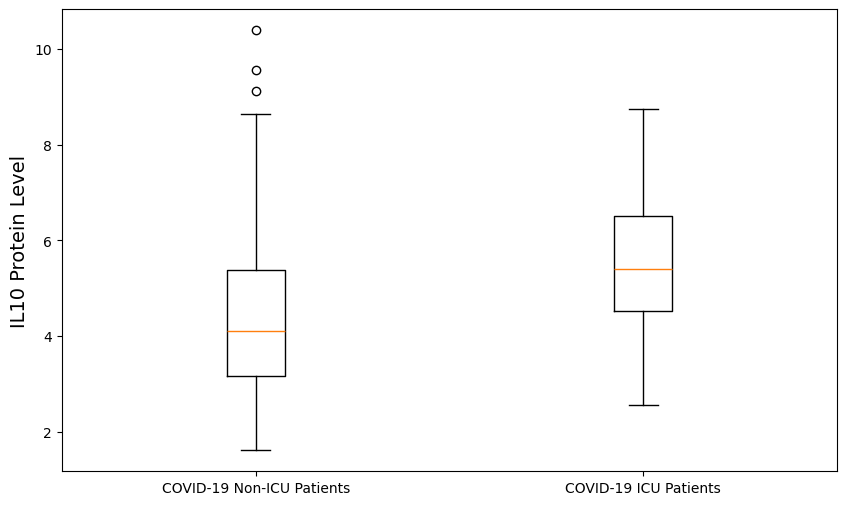

In [178]:
import matplotlib.pyplot as plt


# Create a box plot
plt.figure(figsize=(10, 6))
plt.boxplot([prot["COV_NonICU"], prot["COV_ICU"]], labels=["COVID-19 Non-ICU Patients", "COVID-19 ICU Patients"])

# Add title and labels
plt.ylabel("IL10 Protein Level", fontsize=14)



# Show the plot
plt.show()

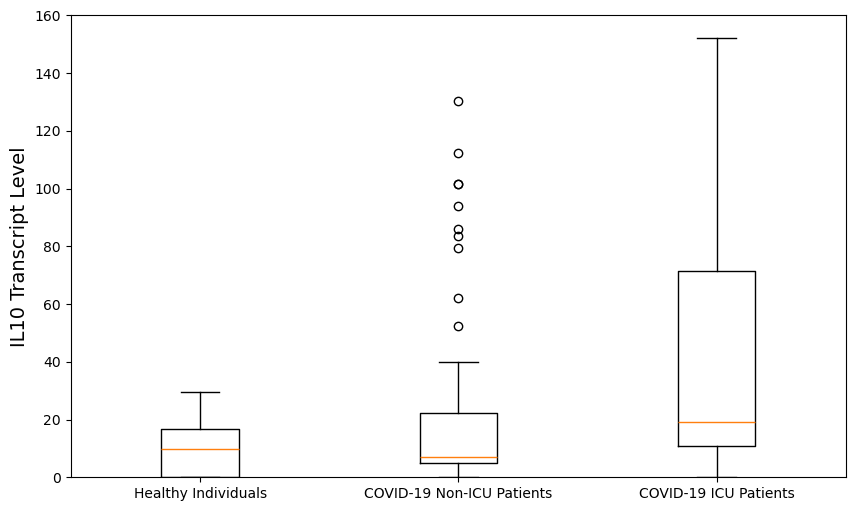

In [179]:
plt.figure(figsize=(10, 6))
plt.boxplot([trans["Healthy"], trans["COV_NonICU"], trans["COV_ICU"]],
            labels=["Healthy Individuals", "COVID-19 Non-ICU Patients", "COVID-19 ICU Patients"])

# Add title and labels
plt.ylabel("IL10 Transcript Level", fontsize=14)

plt.ylim(0, 160)


# Show the plot
plt.show()

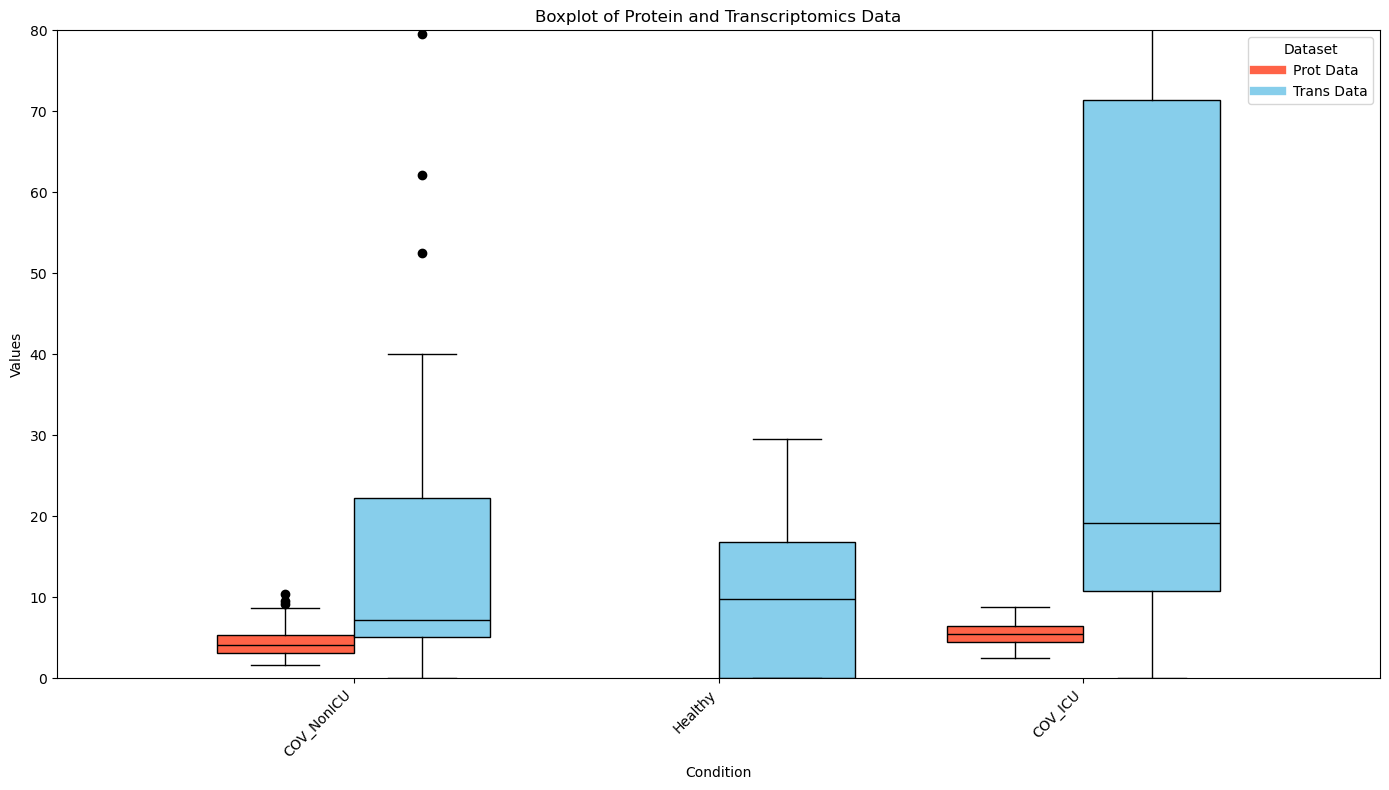

In [57]:
import matplotlib.pyplot as plt
import numpy as np

# Datasets
prot = {
    "COV_NonICU": [4.09828, 5.53249, 7.0425, 5.61502, 5.75945, 5.09637, 5.58118, 4.52962, 9.11822, 5.56637, 7.28338, 7.03475, 4.68609, 4.07684, 4.60683, 6.13969, 4.64185, 6.61635, 5.10558, 4.35867, 6.52305, 5.40673, 7.0035, 3.59793, 5.86441, 6.8065, 5.8343, 4.29305, 4.47559, 5.57231, 5.20881, 3.6098, 7.29027, 3.24616, 3.95417, 3.82972, 4.30983, 4.28034, 3.93563, 6.13889, 4.25928, 4.34324, 3.64441, 4.43039, 4.85452, 4.81186, 3.48025, 3.0601, 3.45481, 3.39294, 8.51657, 3.92789, 4.01341, 6.41352, 4.52991, 6.84667, 6.4103, 4.49563, 5.3474, 10.39345, 4.11268, 4.34763, 4.1334, 4.59485, 3.72483, 3.68611, 7.52825, 4.68082, 4.48222, 3.6854, 3.58999, 5.49008, 3.48402, 4.2935, 7.37413, 4.12829, 5.02649, 3.4696, 3.82203, 7.98324, 3.9961, 4.06784, 5.34856, 5.42156, 3.4994, 3.63254, 4.07071, 3.95252, 4.06553, 6.87295, 3.78601, 4.53577, 4.36048, 6.06201, 4.58574, 5.31471, 3.03932, 4.96735, 5.76468, 4.36853, 4.58734, 3.74166, 4.20125, 2.93981, 8.64287, 3.74178, 6.01482, 5.72802, 2.693, 2.74802, 3.32977, 4.96358, 3.14538, 5.66323, 3.63789, 3.1803, 5.31436, 4.05156, 5.85366, 2.3489, 4.62135, 5.4398, 4.05234, 2.99736, 3.10459, 4.43142, 3.80957, 2.33242, 5.86596, 1.62542, 2.3714, 2.62199, 2.93137, 2.99527, 2.73352, 5.37356, 2.76528, 2.89495, 2.689, 3.47702, 3.7842, 3.25267, 2.22522, 2.11668, 2.52581, 1.61309, 7.33138, 2.81346, 2.55194, 5.85769, 3.29237, 5.58888, 5.23943, 3.01957, 4.15984, 9.56029, 2.7669, 3.3186, 2.90282, 3.09614, 2.4524, 2.42096, 6.40928, 3.34632, 3.15884, 2.59142, 2.53536, 4.00404, 2.60148, 2.84925, 6.02696, 2.92085, 3.81084, 2.26657, 2.5043, 6.95042, 2.72443, 2.78593, 4.16028, 4.29562, 2.42911, 2.45885, 2.79779, 2.74492, 3.1106, 6.26661, 2.62853, 3.47248, 3.13941, 4.66564, 3.30193, 3.89397],
    "COV_ICU": [7.24871, 6.59047, 6.77254, 5.76592, 5.90215, 7.73067, 6.08673, 5.1413, 6.4799, 5.90933, 5.10486, 5.74964, 5.5073, 5.46306, 4.83682, 6.47262, 3.81436, 7.54108, 5.03877, 8.32289, 6.99707, 4.93112, 6.84394, 4.82908, 6.56635, 7.2399, 3.61132, 4.23705, 8.74473, 4.44042, 6.74749, 5.97665, 5.6382, 5.36855, 4.67869, 4.58715, 6.68464, 5.11684, 3.32387, 5.41244, 4.98338, 3.54807, 4.50283, 4.59745, 4.20929, 3.39039, 5.36854, 2.55315, 6.35976, 3.88483, 6.55156, 5.57129, 3.53146, 5.4073, 4.02015, 5.32747, 6.50899, 3.10527, 3.16234, 7.84329, 3.07607, 5.53628]
}

trans = {
    "COV_NonICU": [52.5485, 79.5741, 112.46, 5.98958, 25.5877, 93.9627, 34.4022, 0.0, 9.73513, 101.402, 40.0739, 440.273, 130.361, 24.9031, 101.576, 20.1481, 62.0986, 6.97057, 83.7107, 33.6663, 324.417, 4.73246, 310.819, 5.82991, 0.0, 36.1565, 22.3095, 6.96951, 7.15189, 6.50113, 13.3785, 27.7724, 11.9072, 6.33939, 17.0021, 0.0, 22.8196, 0.0, 4.92159, 31.3072, 11.3784, 6.46463, 0.0, 0.0, 11.8368, 0.0, 12.6427, 5.69178, 11.4041, 4.92349, 12.6971, 0.0, 10.5716, 9.58297, 0.0, 5.66936, 10.5099, 6.07758, 22.2593, 5.6205, 0.0, 37.51, 12.6285, 0.0, 0.0, 0.0, 5.78235, 0.0, 0.0, 5.88772, 5.61858, 6.31019, 5.73357, 12.0193, 0.0, 5.2838, 12.2381, 0.0, 6.19148, 12.5336, 0.0, 7.51344, 5.0738, 18.252, 11.4955, 5.32341, 5.51185, 6.06336, 12.4185, 0.0, 19.5013, 0.0, 4.83368, 11.7027, 5.05675, 6.65131, 85.8416],
    "COV_ICU": [46.1249, 152.292, 10.6194, 1079.01, 309.588, 27.284, 84.0537, 11.8671, 75.1741, 60.3404, 17.4054, 5.01947, 0.0, 13.663, 18.0067, 114.44, 6.11157, 12.4096, 48.0117, 77.6392, 19.9956, 0.0, 70.2213, 0.0, 5.73911, 10.765, 62.5514, 11.2467, 22.4756, 6.10307, 18.2746, 98.407],
    "Healthy": [15.9022, 29.5861, 0.0, 0.0, 17.8375, 22.028, 28.4481, 11.2873, 0.0, 0.0, 10.9388, 0.0, 0.0, 0.0, 9.79587]
}


# Identify all unique columns
all_labels = list(set(prot.keys()) | set(trans.keys()))

# Prepare data for plotting
data = {label: [prot.get(label, []), trans.get(label, [])] for label in all_labels}
colors = ["tomato", "skyblue"]  # Colors for prot and trans

# Create the figure and axis
fig, ax = plt.subplots(figsize=(14, 8))

# Boxplot positions
width = 0.3
positions = np.arange(len(all_labels)) * (width + 0.5)

# Plot each dataset
for i, (label, datasets) in enumerate(data.items()):
    offset = positions[i]
    for j, dataset in enumerate(datasets):
        color = colors[j] if j < len(colors) else 'lightgrey'
        ax.boxplot(dataset, positions=[offset - width/2 + j * width], widths=width, patch_artist=True,
                   boxprops=dict(facecolor=color, color='black'),
                   whiskerprops=dict(color='black'),
                   capprops=dict(color='black'),
                   medianprops=dict(color='black'),
                   flierprops=dict(markerfacecolor='black', marker='o'))

# Set x-ticks and labels
ax.set_xticks(positions)
ax.set_xticklabels(all_labels, rotation=45, ha='right')

# Set y-axis limit
ax.set_ylim(0, 80)

# Add legend
handles = [plt.Line2D([0], [0], color=color, lw=6) for color in colors]
labels = ['Prot Data', 'Trans Data']
ax.legend(handles, labels, loc='upper right', title='Dataset')

# Set labels and title
ax.set_xlabel('Condition')
ax.set_ylabel('Values')
ax.set_title('Boxplot of Protein and Transcriptomics Data')

# Show plot
plt.tight_layout()
plt.show()


In [59]:
import pywikipathways as pwpw

In [60]:
pwpw.get_pathway_info('WP5039')

{'id': 'WP5039',
 'url': 'https://classic.wikipathways.org/index.php/Pathway:WP5039',
 'name': 'SARS-CoV-2 innate immunity evasion and cell-specific immune response',
 'species': 'Homo sapiens',
 'revision': '134359'}

In [61]:
mapped_proteo = pd.read_csv('/Users/firdaws/Documents/TWOCdemonstrator/tools/python_read_omics/mapped_proteomics.csv')
mapped_proteo.head()

,feature.name,Unnamed: 0,database.ID,database,database.version,Uniprot_ID,original,source,mapping,target
0,interleukin 10,106,IL10_HUMAN,https://www.uniprot.org/uniprotkb/,UniProtKB/Swiss-Prot Release 2022_03,P22301,P22301,Uniprot-TrEMBL,P22301,S
1,lymphocyte-activation gene 3,141,LAG3_HUMAN,https://www.uniprot.org/uniprotkb/,UniProtKB/Swiss-Prot Release 2022_03,P18627,P18627,Uniprot-TrEMBL,3902,L
2,TNF receptor-associated factor 2,238,TRAF2_HUMAN,https://www.uniprot.org/uniprotkb/,UniProtKB/Swiss-Prot Release 2022_03,Q12933,Q12933,Uniprot-TrEMBL,ENSG00000127191,En


## TWOC Examples


In [62]:
path_members = pd.read_csv('/Users/firdaws/Documents/TWOCdemonstrator/tools/python_read_omics/geneproducts_IDs.csv')
path_identifiers = path_members.Identifier.to_list()
path_identifiers 

['WP254',
 '3438',
 'Q106020256',
 '84868',
 'ENSG00000104970',
 '424185',
 'AAL65234',
 'YP_009742611',
 'PF15177',
 '6ZSL',
 'Q87917579',
 'Q87917582',
 'Q89226299',
 'YP_009742617',
 'YP_009825053',
 'Q22327223',
 'Q22327229',
 'Q582356',
 'ENSG00000100393',
 'ENSG00000102871',
 'ENSG00000105329',
 'ENSG00000107562',
 'ENSG00000108691',
 'ENSG00000109320',
 'ENSG00000115415',
 'ENSG00000126456',
 'ENSG00000131323',
 'ENSG00000136560',
 'ENSG00000137275',
 'ENSG00000162434',
 'ENSG00000163735',
 'ENSG00000163739',
 'ENSG00000168040',
 'ENSG00000169429',
 'ENSG00000170581',
 'ENSG00000175104',
 'ENSG00000183735',
 'ENSG00000185507',
 'ENSG00000196664',
 'ENSG00000271503',
 'B4DNV3',
 'P01375',
 'P04141',
 'P22301',
 'Q14790',
 '3433',
 'ENSG00000082512',
 'ENSG00000115129',
 'ENSG00000138755',
 'ENSG00000155506',
 'ENSG00000156234',
 'ENSG00000163734',
 'ENSG00000169248',
 'ENSG00000180871',
 '4599',
 '6372',
 '8519',
 'P0DTC3',
 'P0DTC5',
 'P0DTC9',
 'P0DTD2',
 'Q94647436',
 '3902',


In [63]:
transcript_mappings = get_mappings("/Users/firdaws/Documents/TWOCdemonstrator/tools/python_read_omics/transcript_IDs.tsv", "Homo sapiens", "Q", case=1)
transcript_mappings

,original,source,mapping,target
0,NM_130786,RefSeq,3872844,X
1,NM_130786,RefSeq,3872845,X
2,NM_130786,RefSeq,3872842,X
3,NM_130786,RefSeq,8039748,X
4,NM_130786,RefSeq,HGNC:5,Hac
...,...,...,...,...
1739243,NM_015113,RefSeq,ILMN_1786396,Il
1739244,NM_015113,RefSeq,uc059zsd.1,Uc
1739245,NM_015113,RefSeq,23140,L
1739246,NM_015113,RefSeq,GO:0140566,T


In [64]:
transcripts_in_path = transcript_mappings[transcript_mappings['mapping'].isin(path_identifiers )]
transcripts_in_path

,original,source,mapping,target
15450,NM_001371415,RefSeq,ENSG00000130234,En
80628,NM_001030007,RefSeq,B3KNW1,S
171788,NM_001322243,RefSeq,P35613,S
215987,NM_001080124,RefSeq,Q14790,S
235287,NM_002982,RefSeq,ENSG00000108691,En
...,...,...,...,...
1563159,NM_021138,RefSeq,ENSG00000127191,En
1563321,NM_001199427,RefSeq,ENSG00000131323,En
1564044,NM_001033910,RefSeq,ENSG00000082512,En
1564111,NM_004620,RefSeq,ENSG00000175104,En


In [65]:
transcript_meta = pd.read_csv('/Users/firdaws/Documents/TWOCdemonstrator/data/Su_2020_FAIR/transcriptomics/transcriptomics_Su_2020_feature-metadata.csv')
transcript_meta.head(5)

,feature.name,database.ID,database,database.version
0,A1BG,NM_130786,https://www.ncbi.nlm.nih.gov/nuccore/,RefSeq Release 213
1,A1BG-AS1,NR_015380,https://www.ncbi.nlm.nih.gov/nuccore/,RefSeq Release 213
2,A2M,NM_000014,https://www.ncbi.nlm.nih.gov/nuccore/,RefSeq Release 213
3,A2M-AS1,NR_026971,https://www.ncbi.nlm.nih.gov/nuccore/,RefSeq Release 213
4,A2ML1,NM_001282424,https://www.ncbi.nlm.nih.gov/nuccore/,RefSeq Release 213


In [66]:
mapped_transcriptomics = transcript_meta.merge(transcripts_in_path, left_on='database.ID', right_on='original', how='left')
mapped_transcriptomics.dropna(inplace = True)

In [67]:
mapped_transcriptomics

,feature.name,database.ID,database,database.version,original,source,mapping,target
137,ACE2,NM_001371415,https://www.ncbi.nlm.nih.gov/nuccore/,RefSeq Release 213,NM_001371415,RefSeq,ENSG00000130234,En
727,AP1G1,NM_001030007,https://www.ncbi.nlm.nih.gov/nuccore/,RefSeq Release 213,NM_001030007,RefSeq,B3KNW1,S
1584,BSG,NM_001322243,https://www.ncbi.nlm.nih.gov/nuccore/,RefSeq Release 213,NM_001322243,RefSeq,P35613,S
2141,CASP8,NM_001080124,https://www.ncbi.nlm.nih.gov/nuccore/,RefSeq Release 213,NM_001080124,RefSeq,Q14790,S
2358,CCL2,NM_002982,https://www.ncbi.nlm.nih.gov/nuccore/,RefSeq Release 213,NM_002982,RefSeq,ENSG00000108691,En
...,...,...,...,...,...,...,...,...
16392,TRAF2,NM_021138,https://www.ncbi.nlm.nih.gov/nuccore/,RefSeq Release 213,NM_021138,RefSeq,ENSG00000127191,En
16393,TRAF3,NM_001199427,https://www.ncbi.nlm.nih.gov/nuccore/,RefSeq Release 213,NM_001199427,RefSeq,ENSG00000131323,En
16399,TRAF5,NM_001033910,https://www.ncbi.nlm.nih.gov/nuccore/,RefSeq Release 213,NM_001033910,RefSeq,ENSG00000082512,En
16400,TRAF6,NM_004620,https://www.ncbi.nlm.nih.gov/nuccore/,RefSeq Release 213,NM_004620,RefSeq,ENSG00000175104,En


In [68]:
proteo_mappings = get_mappings("/Users/firdaws/Documents/TWOCdemonstrator/tools/python_read_omics/protein_IDs.tsv", "Homo sapiens", "S", case=1)
proteo_mappings

,original,source,mapping,target
0,Q13541,Uniprot-TrEMBL,6BCX,Pd
1,Q13541,Uniprot-TrEMBL,GO:0006417,T
2,Q13541,Uniprot-TrEMBL,6BCU,Pd
3,Q13541,Uniprot-TrEMBL,NM_004095,Q
4,Q13541,Uniprot-TrEMBL,54152_at,X
...,...,...,...,...
29104,Q05516,Uniprot-TrEMBL,3349722,X
29105,Q05516,Uniprot-TrEMBL,3349723,X
29106,Q05516,Uniprot-TrEMBL,ILMN_2402817,Il
29107,Q05516,Uniprot-TrEMBL,231262_at,X


In [70]:
proteo_in_path = proteo_mappings[proteo_mappings['mapping'].isin(path_identifiers )]
proteo_in_path

,original,source,mapping,target
11877,P22301,Uniprot-TrEMBL,P22301,S
12018,P22301,Uniprot-TrEMBL,P22301,S
15916,P18627,Uniprot-TrEMBL,3902,L
15956,P18627,Uniprot-TrEMBL,3902,Wg
27499,Q12933,Uniprot-TrEMBL,ENSG00000127191,En


In [71]:
proteo_meta = pd.read_csv('/Users/firdaws/Documents/TWOCdemonstrator/data/Su_2020_FAIR/proteomics/proteomics_Su_2020_feature-metadata.csv')
proteo_meta.head()

,feature.name,Unnamed: 0,database.ID,database,database.version,Uniprot_ID
0,eukaryotic translation initiation factor 4E bi...,0,4EBP1_HUMAN,https://www.uniprot.org/uniprotkb/,UniProtKB/Swiss-Prot Release 2022_03,Q13541
1,adenosine deaminase,1,ADA_HUMAN,https://www.uniprot.org/uniprotkb/,UniProtKB/Swiss-Prot Release 2022_03,P00813
2,adrenomedullin,2,ADML_HUMAN,https://www.uniprot.org/uniprotkb/,UniProtKB/Swiss-Prot Release 2022_03,P35318
3,anterior gradient 2,3,AGR3_HUMAN,https://www.uniprot.org/uniprotkb/,UniProtKB/Swiss-Prot Release 2022_03,Q8TD06
4,egf-like module containing mucin-like hormone ...,4,AGRE2_HUMAN,https://www.uniprot.org/uniprotkb/,UniProtKB/Swiss-Prot Release 2022_03,Q9UHX3


In [72]:
mapped_proteomics =proteo_meta.merge(proteo_in_path, left_on='Uniprot_ID', right_on='original', how='left')
mapped_proteomics.dropna(inplace = True)

In [73]:
mapped_proteomics


,feature.name,Unnamed: 0,database.ID,database,database.version,Uniprot_ID,original,source,mapping,target
106,interleukin 10,106,IL10_HUMAN,https://www.uniprot.org/uniprotkb/,UniProtKB/Swiss-Prot Release 2022_03,P22301,P22301,Uniprot-TrEMBL,P22301,S
107,interleukin 10,106,IL10_HUMAN,https://www.uniprot.org/uniprotkb/,UniProtKB/Swiss-Prot Release 2022_03,P22301,P22301,Uniprot-TrEMBL,P22301,S
108,interleukin 10,107,IL10_HUMAN,https://www.uniprot.org/uniprotkb/,UniProtKB/Swiss-Prot Release 2022_03,P22301,P22301,Uniprot-TrEMBL,P22301,S
109,interleukin 10,107,IL10_HUMAN,https://www.uniprot.org/uniprotkb/,UniProtKB/Swiss-Prot Release 2022_03,P22301,P22301,Uniprot-TrEMBL,P22301,S
143,lymphocyte-activation gene 3,141,LAG3_HUMAN,https://www.uniprot.org/uniprotkb/,UniProtKB/Swiss-Prot Release 2022_03,P18627,P18627,Uniprot-TrEMBL,3902,L
144,lymphocyte-activation gene 3,141,LAG3_HUMAN,https://www.uniprot.org/uniprotkb/,UniProtKB/Swiss-Prot Release 2022_03,P18627,P18627,Uniprot-TrEMBL,3902,Wg
241,TNF receptor-associated factor 2,238,TRAF2_HUMAN,https://www.uniprot.org/uniprotkb/,UniProtKB/Swiss-Prot Release 2022_03,Q12933,Q12933,Uniprot-TrEMBL,ENSG00000127191,En


In [80]:
prot_features = pd.read_csv('mapped_proteo2.csv')
trans_features = pd.read_csv('mapped_trans2.csv')

In [81]:
common_values = pd.merge(prot_features, trans_features, on='mapping', suffixes=('_prot', '_trans'))

In [82]:
common_values

,feature.name_prot,Unnamed: 0,database.ID_prot,database_prot,database.version_prot,Uniprot_ID,original_prot,source_prot,mapping,target_prot,feature.name_trans,database.ID_trans,database_trans,database.version_trans,original_trans,source_trans,target_trans
0,interleukin 10,106,IL10_HUMAN,https://www.uniprot.org/uniprotkb/,UniProtKB/Swiss-Prot Release 2022_03,P22301,P22301,Uniprot-TrEMBL,P22301,S,IL10,NM_000572,https://www.ncbi.nlm.nih.gov/nuccore/,RefSeq Release 213,NM_000572,RefSeq,S
1,lymphocyte-activation gene 3,141,LAG3_HUMAN,https://www.uniprot.org/uniprotkb/,UniProtKB/Swiss-Prot Release 2022_03,P18627,P18627,Uniprot-TrEMBL,3902,L,LAG3,NM_002286,https://www.ncbi.nlm.nih.gov/nuccore/,RefSeq Release 213,NM_002286,RefSeq,L
2,TNF receptor-associated factor 2,238,TRAF2_HUMAN,https://www.uniprot.org/uniprotkb/,UniProtKB/Swiss-Prot Release 2022_03,Q12933,Q12933,Uniprot-TrEMBL,ENSG00000127191,En,TRAF2,NM_021138,https://www.ncbi.nlm.nih.gov/nuccore/,RefSeq Release 213,NM_021138,RefSeq,En
